# Memory Experiment — the [[n, n−4, 2]] H-code family

**[DEMO]** — uses `HCode`, its dedicated concurrent extraction, and the
packaged `MemoryExperiment`. Change **N** below to inspect another even size.
`HSixCode()` delegates to `HCode(n=6)` and preserves the original H6 convention.

Initial H6 assets contributed by **Maggie Bao (Infleqtion)** in
[PR #98](https://github.com/QuTone/LightStim/pull/98).
Family reference: [Jones, Section II](https://arxiv.org/pdf/1210.3388).
Magic-H6 reference: [Dasu et al.](https://arxiv.org/html/2506.14688v1).
See the [family README](../../lightstim/qec_code/H_code/README.md) for the
schedule and the [integration walkthrough](../../docs/design/h6_core_integration.md)
for provenance and later milestones.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "lightstim").is_dir() and (path / "pyproject.toml").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import stim
from lightstim.noise.config import NoiseConfig
from lightstim.protocols.memory import MemoryExperiment
from lightstim.ir.qec_system import QECSystem
from lightstim.qec_code.H_code import HCode, HCodeExtractionBlock, HSixCode
from IPython.display import SVG, display

print("Python:", sys.version.split()[0], "Stim:", stim.__version__)

Python: 3.10.12 Stim: 1.15.0


## 1. Family definition and H6 compatibility

For even **n ≥ 6**, the two check supports are `A=(0,1,2,3)` and
`B=(2,3,...,n−1)`, for both X and Z. Four independent checks leave **k=n−4**
logical qubits. For `q=4,...,n−1`, logical slot `j=q−4` uses `(0,2,q)` when
q is even and `(1,3,q)` when q is odd, for both X and Z.

For H6 this is exactly `XL0=X0 X2 X4`, `XL1=X1 X3 X5`, and the matching Z
operators. Logical pairs are registered `(XL0,ZL0,XL1,ZL1,...)`. Matching X/Z
supports give transversal H on every logical slot. The distance is two:
`X0 X1` is a weight-two logical even though the chosen representatives weigh
three. Increasing n increases k, while d stays two; HCode(n=36) is [[36,32,2]],
not the concatenated [[36,4,4]] Magic-H6 construction.

In [2]:
N = 8  # Any even integer >= 6; set N=6 to inspect the original H6.
ROUNDS = 3
SE_BLOCK = HCodeExtractionBlock  # Explicit extraction choice for this demo.
patch = HCode(n=N)
print("Configured SE:", SE_BLOCK.__name__)
print("Patch default SE:", patch.default_extraction_block_class.__name__)
assert HSixCode().stabilizers == HCode(n=6).stabilizers
assert HSixCode().logical_ops == HCode(n=6).logical_ops
info = patch.get_info()
print({key: info[key] for key in ("code_distance", "k", "n_data",
                                  "num_x_syndromes", "num_z_syndromes")})
hx, hz = patch.get_parity_check_matrix()
assert np.array_equal(hx, hz) and not ((hx @ hz.T) % 2).any()
for s in patch.stabilizers:
    print(f"{s['type']}-check: data={s['data_indices']}, ancilla={s['syn_idx']}")
for op in patch.logical_ops:
    print(f"logical {op['type']}: {op['data_indices']}")

Configured SE: HCodeExtractionBlock
Patch default SE: HCodeExtractionBlock
{'code_distance': 2, 'k': 4, 'n_data': 8, 'num_x_syndromes': 2, 'num_z_syndromes': 2}
X-check: data=[0, 1, 2, 3], ancilla=8
X-check: data=[2, 3, 4, 5, 6, 7], ancilla=9
Z-check: data=[0, 1, 2, 3], ancilla=10
Z-check: data=[2, 3, 4, 5, 6, 7], ancilla=11
logical X: [0, 2, 4]
logical Z: [0, 2, 4]
logical X: [1, 3, 5]
logical Z: [1, 3, 5]
logical X: [0, 2, 6]
logical Z: [0, 2, 6]
logical X: [1, 3, 7]
logical Z: [1, 3, 7]


## 2. Tanner graphs and coordinate convention

Data i sits at **(2i,0)**. Check ancillas sit at their support centroids:
**(3,±1)** and **(n+1,±1)**. Circles are data; squares are ancillas. An edge
means the data qubit belongs to that check. Red is X; blue is Z.
`shift=(dx,dy)` moves the whole patch. These drawing coordinates do not impose
a nearest-neighbor hardware constraint.

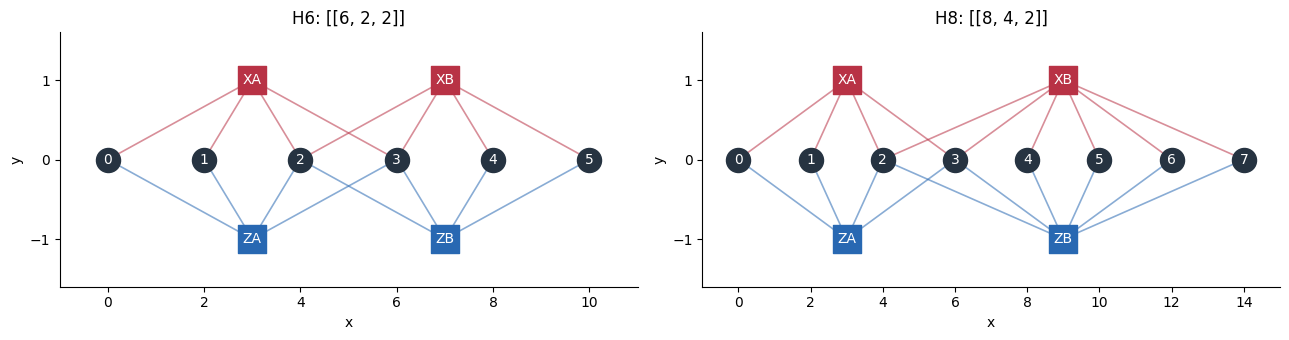

In [3]:
colors = {"X": "#b83245", "Z": "#2868b2"}
def draw_tanner(code_patch, ax):
    for basis in ("X", "Z"):
        checks = [s for s in code_patch.stabilizers if s["type"] == basis]
        for label, s in zip(("A", "B"), checks):
            sx, sy = code_patch.qubit_coords[s["syn_idx"]]
            for q in s["data_indices"]:
                x, y = code_patch.qubit_coords[q]
                ax.plot([sx, x], [sy, y], color=colors[basis], alpha=.55, lw=1.2)
            ax.scatter(sx, sy, marker="s", s=400, color=colors[basis], zorder=3)
            ax.text(sx, sy, f"{basis}{label}", color="white", ha="center", va="center", zorder=4)
    for q in sorted(code_patch.data_indices):
        x, y = code_patch.qubit_coords[q]
        ax.scatter(x, y, s=300, color="#263341", zorder=3)
        ax.text(x, y, str(q), color="white", ha="center", va="center", zorder=4)
    n = code_patch.n
    ax.set(xlim=(-1, 2*n-1), ylim=(-1.6, 1.6), xlabel="x", ylabel="y",
           title=f"H{n}: [[{n}, {n-4}, 2]]")
    ax.set_xticks(range(0, 2*n, 2))
    ax.set_yticks([-1, 0, 1])
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for pch, ax in zip((HSixCode(), patch), axes):
    draw_tanner(pch, ax)
fig.tight_layout()
plt.show()

## 3. Concurrent X/Z extraction: n+2 CNOT layers

All four checks advance in one pipeline. Each check touches shared data 2
first, its private data next, and shared data 3 last. XA, XB, ZA, ZB start
one layer apart. Every X interaction on a data qubit precedes every Z
interaction on that same qubit; X and Z interactions on different data
qubits overlap. The ideal unitary is equivalent to serial X-then-Z extraction.

Each colored box below is one CNOT and shows its **data label**; the row
identifies its ancilla. X CNOTs point ancilla→data; Z CNOTs point data→ancilla.
White boxes are idle. There are **2n+4 CNOTs**, **n+2 CNOT layers**, and four
additional operation layers (reset, H, H, measurement). All ancillas are
measured together. This block has no flag ancillas.

H8: 10 CNOT layers; 20 CNOTs; 4 syndrome ancillas
 n   k   dedicated CX depth   generic CX depth
 6   2           8                   8
 8   4          10                  12
10   6          12                  16
12   8          14                  20
16  12          18                  28


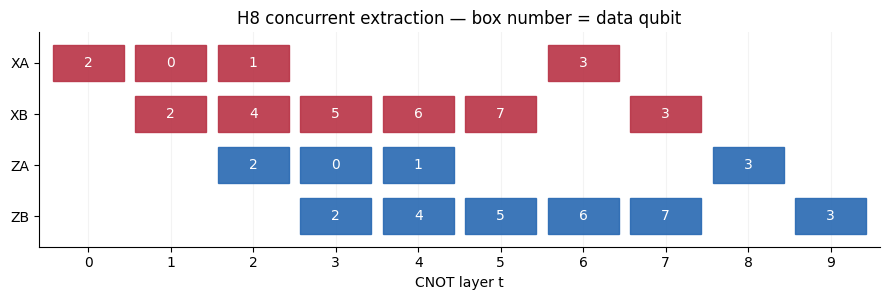

In [4]:
system = QECSystem()
system.add_patch(patch, name="h")
se = SE_BLOCK(system)
print(f"H{N}: {se.cnot_depth} CNOT layers; "
      f"{sum(map(len, se.cnot_layers))} CNOTs; 4 syndrome ancillas")
print(" n   k   dedicated CX depth   generic CX depth")
for n in (6, 8, 10, 12, 16):
    print(f"{n:2}  {n-4:2}          {n+2:2}                  {2*(n-2):2}")

fig, ax = plt.subplots(figsize=(max(9, .65*se.cnot_depth), 3.1))
from matplotlib.patches import Rectangle
row_for_ancilla = {N+i: i for i in range(4)}
for basis, layers in (("X", se.x_layers), ("Z", se.z_layers)):
    for t, layer in enumerate(layers):
        for ancilla, data in layer:
            row = row_for_ancilla[ancilla]
            ax.add_patch(Rectangle((t-.43, row-.36), .86, .72,
                                   color=colors[basis], alpha=.9))
            ax.text(t, row, str(data), ha="center", va="center", color="white")
ax.set(xlim=(-.6, se.cnot_depth-.4), ylim=(3.6, -.6), xlabel="CNOT layer t",
       title=f"H{N} concurrent extraction — box number = data qubit")
ax.set_xticks(range(se.cnot_depth))
ax.set_yticks(range(4), ["XA", "XB", "ZA", "ZB"])
ax.grid(axis="x", alpha=.15)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Bare X/Z memory with automatic detectors

Data starts in a product state in the memory basis. The first extraction
projects unfixed checks; later rounds compare outcomes. Final data readout
supplies the matching boundary checks. `CircuitBuilder` and `SyndromeTracker`
construct detectors and all k logical observables automatically. For r rounds,
either basis has **4r detectors** and **n−4 observables**.

### Where the extraction block comes from

`extraction_block_class` is an optional configuration. An explicit value wins;
otherwise `MemoryExperiment` reads the patch's `default_extraction_block_class`.
For `HCode` (and `HSixCode`) this is `HCodeExtractionBlock`, registered in
[`H_code/__init__.py`](../../lightstim/qec_code/H_code/__init__.py). If no patch
provides a default, the generic CSS coloration block is the fallback. Systems
with conflicting patch defaults must specify the block explicitly.

This notebook explicitly passes **`extraction_block_class=SE_BLOCK`** for both
noiseless and noisy memory, and uses the same class for the schedule figure.
Omitting it would select the same dedicated block here. The original H6 PR
also registered a default, but its `HSixExtractionBlock` aliased the generic
CSS coloration block. `basis` chooses the data preparation/readout basis;
the dedicated SE still measures both X and Z checks each round.

In [5]:
circuits = {}
print(" n  basis  qubits  detectors  observables")
for n in sorted({6, 8, 12, N}):
    for basis in ("Z", "X"):
        c = MemoryExperiment(
            qec_patch=HCode(n=n), extraction_block_class=SE_BLOCK,
            rounds=ROUNDS, basis=basis,
        ).build()
        dets, obs = c.compile_detector_sampler(seed=98).sample(256, separate_observables=True)
        assert c.num_observables == n-4 and c.num_detectors == 4*ROUNDS
        assert not dets.any() and not obs.any()
        c.detector_error_model()
        print(f"{n:2}    {basis}      {c.num_qubits:2}       {c.num_detectors:2}          {c.num_observables:2}")
        if n == N:
            circuits[basis] = c
print("All noiseless detector and logical checks passed.")

 n  basis  qubits  detectors  observables
 6    Z      10       12           2
 6    X      10       12           2
 8    Z      12       12           4
 8    X      12       12           4
12    Z      16       12           8
12    X      16       12           8
All noiseless detector and logical checks passed.


### Detector slices

In Z memory, first-round and final-readout boundaries constrain Z checks;
interior rounds compare both X and Z checks. This view shows part of one
extraction cycle; use `circuits["Z"]` or `circuits["X"]` to inspect the full
circuit interactively.

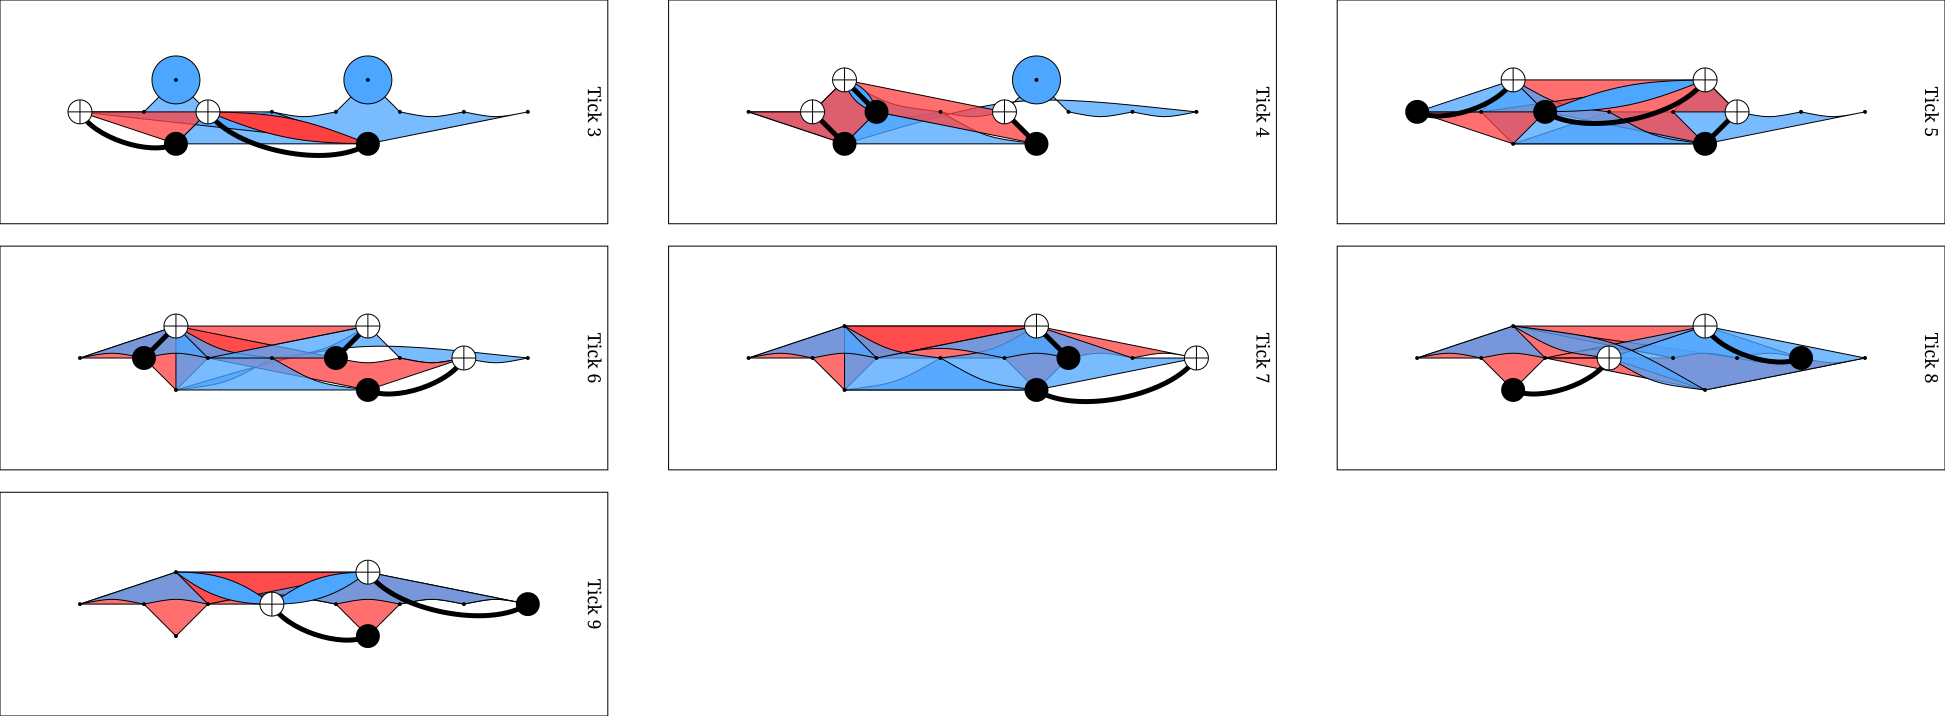

In [6]:
display(SVG(str(circuits["Z"].diagram(
    "detslice-with-ops-svg", tick=range(3, min(10, circuits["Z"].num_ticks))
))))

## 5. Circuit fault distance: lower and upper bounds

Use independent Pauli gate/SPAM noise with
`p_1q = p_2q = p_meas = p_reset = p` and `p_idle = 0`.

The **undecomposed DEM** preserves all single-fault signatures, including
hyperedges. There must be no term that flips a logical without a detector.
This proves a lower bound of two under the specified noise model.
A graphlike two-fault witness with independent physical locations provides
the matching upper bound. Default graphlike search alone skips hyperedges;
`ignore_ungraphlike_errors=False` attempts decomposition and is not an
exhaustive hyperedge search.

In [7]:
p = 0.008
noisy_circuits = {}
for basis in ("Z", "X"):
    c = MemoryExperiment(
        qec_patch=HCode(n=N), extraction_block_class=SE_BLOCK,
        rounds=2, basis=basis,
        noise_params=NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=0),
        noise_model="circuit_level",
    ).build()
    errors = [e for e in c.detector_error_model(decompose_errors=False).flattened()
              if e.type == "error"]
    undetected = [e for e in errors
                  if any(t.is_logical_observable_id() for t in e.targets_copy())
                  and not any(t.is_relative_detector_id() for t in e.targets_copy())]
    assert errors and not undetected
    witness = c.shortest_graphlike_error(canonicalize_circuit_errors=True)
    assert len(witness) == 2 and all(e.circuit_error_locations for e in witness)
    a, b = [e.circuit_error_locations[0] for e in witness]
    if a.stack_frames == b.stack_frames:
        ta, tb = a.instruction_targets, b.instruction_targets
        assert (ta.target_range_end <= tb.target_range_start
                or tb.target_range_end <= ta.target_range_start)
    print(f"{basis}: {len(errors)} nontrivial DEM signatures; "
          "undetected single faults=0; independent two-fault witness found")
    noisy_circuits[basis] = c

Z: 107 nontrivial DEM signatures; undetected single faults=0; independent two-fault witness found
X: 107 nontrivial DEM signatures; undetected single faults=0; independent two-fault witness found


## 6. Acceptance and conditional block error

Accept a shot only if **every detector** is zero, including final readout
checks. Count an accepted shot as a failure if **any of the n−4 logical observables**
flips. This is an error-detecting memory result without a decoder; no special
flag postselection tags are present in this baseline.

The following is a small single-p sample, not a slope estimate. A reproducible
four-p sweep lives in `tests/test_H_code_fault_distance.py` (slow tests).

In [8]:
shots = 100_000
for basis, c in noisy_circuits.items():
    dets, obs = c.compile_detector_sampler(seed=1098).sample(shots, separate_observables=True)
    accepted = ~dets.any(axis=1)
    n_accepted = int(accepted.sum())
    assert n_accepted > 0
    failures = int(obs[accepted].any(axis=1).sum())
    print(f"{basis}: p={p:g}, shots={shots}, accepted={n_accepted} "
          f"({n_accepted / shots:.2%}), failures={failures}, "
          f"conditional block error={failures / n_accepted:.6g}")

Z: p=0.008, shots=100000, accepted=55939 (55.94%), failures=127, conditional block error=0.00227033
X: p=0.008, shots=100000, accepted=56207 (56.21%), failures=153, conditional block error=0.00272208


## 7. Validation results and next boundary

The exact undecomposed single-fault audit and independent two-fault witness
pass for **n=6,8,12,20,32,64**, both bases, 1–3 rounds, with and without idle
noise. They establish circuit fault distance two for these tested, destructively
read out memory circuits. They do not establish open-output extraction fault
tolerance or arbitrary protocol composition.

The dedicated schedule's four-p regression sweep used p=0.002,0.004,0.008,0.016,
400,000 shots per point, rounds=2, seeds 98–101, and no idle noise (Stim 1.15.0):

| Code | Z-memory fitted slope | X-memory fitted slope |
|---|---:|---:|
| H6 | 1.9947 | 1.9653 |
| H10 | 2.0662 | 2.0583 |

These are empirical checks of quadratic conditional block error. Finite-shot
samples can differ across versions or platforms; the single-fault exclusion
provides the stronger small-p evidence. The preceding sample is for the
selected N at one p, not a slope estimate.

The next flag circuit will be a **separate H6-only extraction block**. General
H-family flags are outside this milestone. Flagged preparation, Magic-H6
proxies, concatenation, and true non-Clifford output-state validation each
need their own acceptance and error criteria.

```bash
PYTHONPATH=. venv/bin/python -m pytest tests/test_H_code_fault_distance.py -m slow -s
```